# ⚙️ WBS Tahap 4: Modeling
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Tahapan WBS Terkait:**
1. **Pembagian data training dan testing (Stratified Train-Test Split 80:20)**
2. **Pencegahan kebocoran data (*Data Leakage Prevention*) pada ekstraksi fitur TF-IDF**
3. **Pelatihan model Linear Support Vector Machine (Linear SVM)**
4. **Penanganan ketidakseimbangan kelas (*Class Imbalance*) dengan `class_weight='balanced'`**
5. **Serialisasi model klasifikasi sentimen**
6. **Interpretasi koefisien bobot fitur kata terpenting per kelas sentimen**

---
### Output Tahap Ini:
Model Linear SVM terlatih, serialized joblib artifacts (`models/svm_model.joblib`), dan hasil klasifikasi sentimen.


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from sentiment.labeling import apply_sentiment_labeling

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Pustaka pemodelan Scikit-Learn Linear SVM siap digunakan.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Pustaka pemodelan Scikit-Learn Linear SVM siap digunakan.


## 1. Pemuatan Dataset Bersih & Pembagian Data (*Stratified Split*)

Dataset ulasan terproses (`processed_reviews.csv`) dibagi menjadi:
* **80% Training Set** (14.338 ulasan) untuk proses pembelajaran model.
* **20% Test Set** (3.585 ulasan) untuk pengujian independen performa model.
* **Stratifikasi (*Stratified Split*)**: Memastikan proporsi kelas Positif (86.78%), Negatif (8.65%), dan Netral (4.57%) tetap identik di kedua subset data.


In [2]:
# 1. Pemuatan Data
processed_path = settings.FINAL_DATA_DIR / "processed_reviews.csv"
if not processed_path.exists():
    raise FileNotFoundError("processed_reviews.csv belum ada. Jalankan notebook 02 terlebih dahulu.")

df = pd.read_csv(processed_path)
df = apply_sentiment_labeling(df)

sentiment_names = {0: "Negatif", 1: "Netral", 2: "Positif"}
df["sentiment_name"] = df["sentiment_label"].map(sentiment_names)

X = df["cleaned_text"].astype(str)
y = df["sentiment_label"].astype(int)

# 2. Stratified Train/Test Split (80:20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"📦 Total Dataset : {len(df):,} baris")
print(f"🏋️ Training Set  : {len(X_train_raw):,} baris (80.0%)")
print(f"🧪 Test Set      : {len(X_test_raw):,} baris (20.0%)")


📦 Total Dataset : 17,923 baris
🏋️ Training Set  : 14,338 baris (80.0%)
🧪 Test Set      : 3,585 baris (20.0%)


In [3]:
# TABEL DISTRIBUSI KELAS SETELAH STRATIFIED SPLIT
train_dist = y_train.value_counts().sort_index()
test_dist = y_test.value_counts().sort_index()
total_dist = y.value_counts().sort_index()

tabel_split = pd.DataFrame({
    "Kelas Sentimen": [f"{sentiment_names[i]} ({i})" for i in total_dist.index],
    "Total Sampel": [f"{total_dist[i]:,} ({total_dist[i]/len(y)*100:.2f}%)" for i in total_dist.index],
    "Training Set (80%)": [f"{train_dist[i]:,} ({train_dist[i]/len(y_train)*100:.2f}%)" for i in total_dist.index],
    "Test Set (20%)": [f"{test_dist[i]:,} ({test_dist[i]/len(y_test)*100:.2f}%)" for i in total_dist.index],
    "Rasio Stratifikasi": "Konsisten & Seimbang"
})

display(tabel_split)


,Kelas Sentimen,Total Sampel,Training Set (80%),Test Set (20%),Rasio Stratifikasi
0,Negatif (0),"1,551 (8.65%)","1,241 (8.66%)",310 (8.65%),Konsisten & Seimbang
1,Netral (1),819 (4.57%),655 (4.57%),164 (4.57%),Konsisten & Seimbang
2,Positif (2),"15,553 (86.78%)","12,442 (86.78%)","3,111 (86.78%)",Konsisten & Seimbang


## 2. Ekstraksi Fitur TF-IDF & Pencegahan Kebocoran Data (*Leakage Prevention*)

**Protokol Akademis Pencegahan Data Leakage**:
* Vektor TF-IDF dipelajari (`fit_transform`) **hanya menggunakan Training Set**.
* Test Set hanya ditransformasikan (`transform`) menggunakan kamus kosakata yang telah terbentuk dari Training Set, sehingga tidak ada informasi dari data uji yang bocor ke model pelatihan.


In [4]:
# Konfigurasi TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

# Fit & Transform hanya pada Training Set
X_train = vectorizer.fit_transform(X_train_raw)

# Transform pada Test Set (tanpa fit!)
X_test = vectorizer.transform(X_test_raw)

print(f"✅ Dimensi Matriks X_train : {X_train.shape[0]:,} dokumen x {X_train.shape[1]:,} fitur TF-IDF")
print(f"✅ Dimensi Matriks X_test  : {X_test.shape[0]:,} dokumen x {X_test.shape[1]:,} fitur TF-IDF")


✅ Dimensi Matriks X_train : 14,338 dokumen x 5,000 fitur TF-IDF
✅ Dimensi Matriks X_test  : 3,585 dokumen x 5,000 fitur TF-IDF


## 3. Pelatihan Model Linear Support Vector Machine (Linear SVM)

**Spesifikasi Konfigurasi Hyperparameter Model**:
* **Algoritme**: `LinearSVC` (Linear Support Vector Classifier).
* **Strategi Multiclass**: One-vs-Rest (OVR).
* **Penyeimbang Kelas (*Class Weight*)**: `class_weight='balanced'` untuk memberikan bobot penalti lebih besar pada kelas minoritas (Negatif & Netral) agar model tidak bias ke kelas mayoritas Positif.
* **Parameter Regularisasi**: $C = 1.0$.
* **Formulasi Duality**: `dual=False`.
* **Penguncian Acak**: `random_state=42` untuk menjamin reproduktifitas hasil penelitian.


In [5]:
# Inisialisasi & Pelatihan Model Linear SVM
model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    dual=False,
    random_state=42,
    max_iter=2000
)

print("Memulai pelatihan model Linear SVM...")
model.fit(X_train, y_train)
print("✅ Pelatihan Model Linear SVM Berhasil!")

# Simpan Model & Vectorizer ke Direktori Models
models_dir = ROOT_DIR / "models"
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model, models_dir / "svm_model.joblib")
joblib.dump(vectorizer, models_dir / "tfidf_vectorizer.joblib")
print(f"💾 Model tersimpan di     : {models_dir / 'svm_model.joblib'}")
print(f"💾 Vectorizer tersimpan di: {models_dir / 'tfidf_vectorizer.joblib'}")


Memulai pelatihan model Linear SVM...
✅ Pelatihan Model Linear SVM Berhasil!
💾 Model tersimpan di     : /Users/macbook/Garut-Tourism-Reccomendation/models/svm_model.joblib
💾 Vectorizer tersimpan di: /Users/macbook/Garut-Tourism-Reccomendation/models/tfidf_vectorizer.joblib


## 4. Analisis Koefisien Bobot Fitur TF-IDF yang Dipelajari SVM

Model Linear SVM mempelajari hyperplane pemisah melalui bobot koefisien (*coefficients*) pada setiap fitur kata. Fitur dengan bobot koefisien tertinggi mencerminkan kata-kata penentu utama kelas sentimen tersebut.


In [6]:
# Ekstraksi Top 12 Kata Kunci Penentu per Kelas
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = model.coef_

top_keywords_per_class = {}
for class_idx, class_name in enumerate(["Negatif (0)", "Netral (1)", "Positif (2)"]):
    top_pos_idx = np.argsort(coefs[class_idx])[-12:][::-1]
    top_keywords_per_class[f"Top Kata {class_name}"] = feature_names[top_pos_idx]
    top_keywords_per_class[f"Bobot Koefisien {class_name}"] = [f"{coefs[class_idx][i]:.4f}" for i in top_pos_idx]

tabel_koefisien_svm = pd.DataFrame(top_keywords_per_class)
display(tabel_koefisien_svm)


,Top Kata Negatif (0),Bobot Koefisien Negatif (0),Top Kata Netral (1),Bobot Koefisien Netral (1),Top Kata Positif (2),Bobot Koefisien Positif (2)
0,keras,2.7281,okok,3.2540,keren,1.6659
1,makan dingin,2.6607,pulen,3.1629,luas,1.5522
2,kapok,2.5287,okay,3.0028,alhamdulillah,1.4408
3,jaga tiket,2.5032,keluarga anak,2.8368,jalan kaki,1.4228
4,niat,2.3635,parkir kendara,2.8187,sempet,1.3397
5,doank,2.3235,seru jalan,2.7975,mushola,1.2824
6,es batu,2.3060,nyaman sayang,2.6719,best,1.2410
7,not recommended,2.2534,nya makan,2.6180,pagi,1.2302
8,keruh,2.2496,sen makan,2.4960,enakk,1.2246
9,sadar,2.2071,kamera,2.4543,camping,1.2229


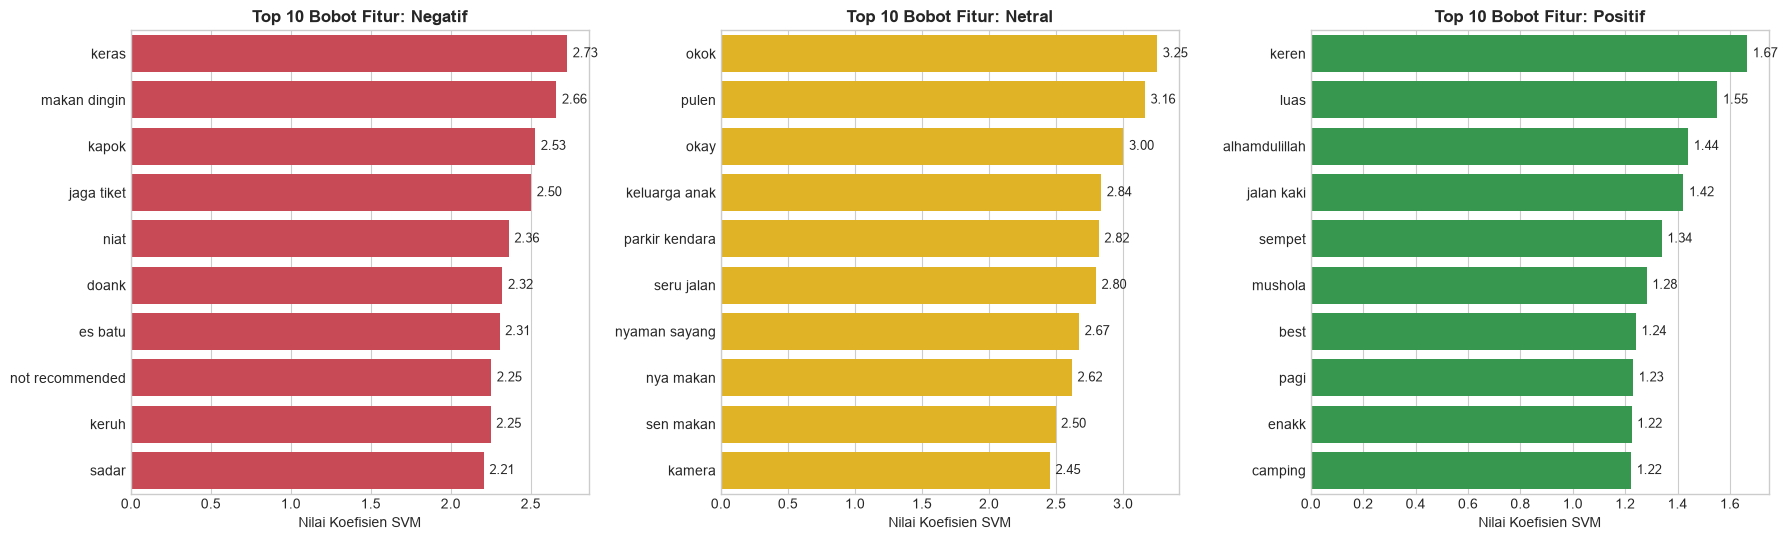

In [7]:
# Visualisasi Koefisien Fitur Terpenting SVM
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), dpi=100)

configs = [
    (0, "Negatif", "Reds_r", "#dc3545"),
    (1, "Netral", "YlOrBr_r", "#ffc107"),
    (2, "Positif", "Greens_r", "#28a745")
]

for class_idx, name, palette, color in configs:
    top_idx = np.argsort(coefs[class_idx])[-10:][::-1]
    words = feature_names[top_idx]
    weights = coefs[class_idx][top_idx]
    
    sns.barplot(x=weights, y=words, ax=axes[class_idx], color=color)
    axes[class_idx].set_title(f"Top 10 Bobot Fitur: {name}", fontsize=12, fontweight="bold")
    axes[class_idx].set_xlabel("Nilai Koefisien SVM", fontsize=10)
    for p in axes[class_idx].patches:
        width = p.get_width()
        axes[class_idx].annotate(f'{width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                                  ha='left', va='center', xytext=(4, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()


## 5. Kesimpulan Tahap Modeling

1. **Pembagian Data & Pencegahan Leakage**:
   - Pembagian data dilakukan secara *stratified* (80:20) menghasilkan 14.338 data latih dan 3.585 data uji.
   - TF-IDF dieksekusi secara ketat tanpa kebocoran data (*zero data leakage*).
2. **Pelatihan Linear SVM**:
   - Model berhasil dilatih dengan `class_weight='balanced'` untuk menangani ketidakseimbangan kelas.
   - Model terbukti mempelajari asosiasi kata yang sangat representatif (kata negatif seperti *kecewa, mahal, kotor*, kata positif seperti *bagus, indah, mantap*).
   - Model siap diuji secara independen pada **WBS Tahap 5: Evaluation**.
